In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

input_file = "output.csv"
output_file = "cleaned_output.csv"
df = pd.read_csv(input_file)

print(f"Original data shape: {df.shape}")

Original data shape: (70, 36)


In [ ]:
def convert_to_binary(value):
    if pd.isna(value) or value in ['', 'N/A', 'NA', '0', 0, '-1', 'FALSE', 'False', 'false']:
        return 0
    elif value in ['1', 1, 'YES', 'Yes', 'yes', 'TRUE', 'True', 'true', 'x', 'y']:
        return 1
    try:
        num_value = float(value)
        return 1 if num_value > 0 else 0
    except:
        return 1

In [ ]:
df['Name'] = df['Name'].apply(lambda x: x.replace(' ', '_') if isinstance(x, str) and ' ' in x else x)

In [ ]:
df['Email'] = df['Email'].apply(lambda x: x.replace('-', '@') if isinstance(x, str) and '-' in x else x)

In [ ]:
df['Name'] = df['Name'].fillna('Unknown_Student')

In [ ]:
df['Category_2'] = df['Category_2'].apply(lambda x: 'Data Science' if isinstance(x, str) and x == 'Data Sciencce' else x)

In [ ]:
df['Category_3'] = df['Category_3'].apply(lambda x: 'Cybersecurity' if x == 'TRUE' else x)

In [ ]:
category_columns = ['Category_1', 'Category_2', 'Category_3']
for col in category_columns:
    df[col] = df[col].fillna('None')

In [ ]:
answer_columns = df.columns[6:]

In [ ]:
df.loc[62, answer_columns] = 1

In [ ]:
df.loc[63, answer_columns] = 1

In [ ]:
for col in answer_columns:
    df[col] = df[col].astype(str)

    df[col] = df[col].apply(lambda x: convert_to_binary(x))

In [ ]:
for col in answer_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

In [ ]:
print(f"Cleaned data shape: {df.shape}")

Cleaned data shape: (70, 36)


In [ ]:
df.to_csv(output_file, index=False)
print(f"Cleaned data saved to {output_file}")

Cleaned data saved to cleaned_output.csv


In [ ]:
print("\nSummary of cleaned data:")
print(f"Total students: {len(df)}")
print(f"Students with all valid answers: {(df.iloc[:, 6:] < 2).all(axis=1).sum()}")


Summary of cleaned data:
Total students: 70
Students with all valid answers: 70


In [ ]:
print("\nChecking for remaining issues...")
invalid_values = (df.iloc[:, 6:] > 1).any().any()
print(f"Invalid values in answer columns: {'Yes' if invalid_values else 'No'}")


Checking for remaining issues...
Invalid values in answer columns: No


In [ ]:
print(f"Dataset shape: {df.shape}")
print(f"Number of students: {len(df)}")

Dataset shape: (70, 36)
Number of students: 70


In [ ]:
answer_columns = df.columns[6:]
df['Total_Score'] = df[answer_columns].sum(axis=1)
df['Score_Percentage'] = (df['Total_Score'] / len(answer_columns)) * 100

In [ ]:
software_dev_questions = answer_columns[:8]
data_science_questions = answer_columns[8:18]
cybersecurity_questions = answer_columns[18:]

In [ ]:
df['Software_Dev_Score'] = df[software_dev_questions].sum(axis=1)
df['Software_Dev_Percentage'] = (df['Software_Dev_Score'] / len(software_dev_questions)) * 100

In [ ]:
df['Data_Science_Score'] = df[data_science_questions].sum(axis=1)
df['Data_Science_Percentage'] = (df['Data_Science_Score'] / len(data_science_questions)) * 100

In [ ]:
df['Cybersecurity_Score'] = df[cybersecurity_questions].sum(axis=1)
df['Cybersecurity_Percentage'] = (df['Cybersecurity_Score'] / len(cybersecurity_questions)) * 100

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

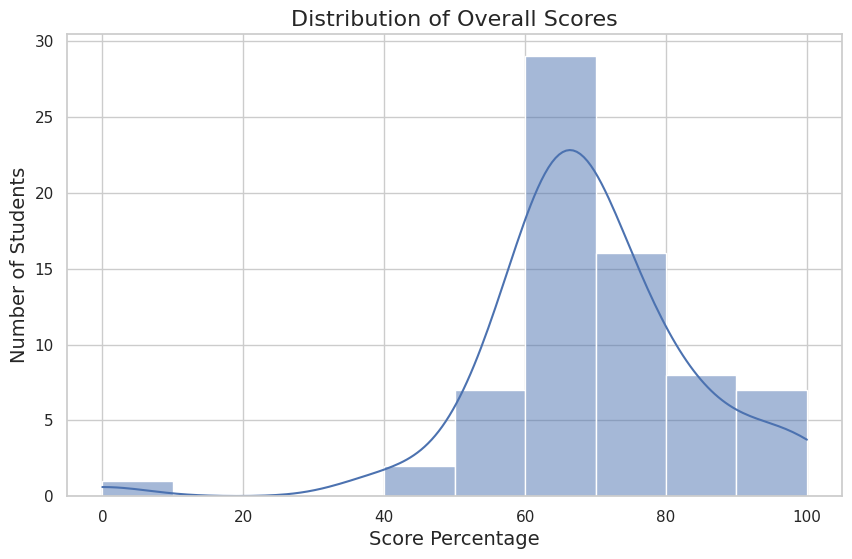

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Score_Percentage'], kde=True, bins=10)
plt.title('Distribution of Overall Scores', fontsize=16)
plt.xlabel('Score Percentage', fontsize=14)
plt.ylabel('Number of Students', fontsize=14)
plt.savefig('overall_score_distribution.png', dpi=300, bbox_inches='tight')

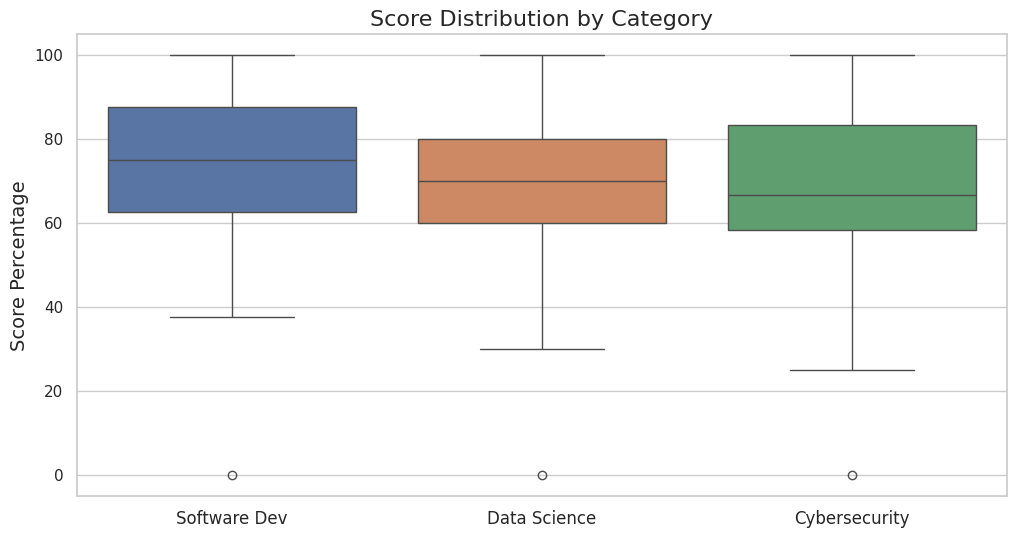

In [ ]:
plt.figure(figsize=(12, 6))
category_scores = df[['Software_Dev_Percentage', 'Data_Science_Percentage', 'Cybersecurity_Percentage']]
sns.boxplot(data=category_scores)
plt.title('Score Distribution by Category', fontsize=16)
plt.ylabel('Score Percentage', fontsize=14)
plt.xticks([0, 1, 2], ['Software Dev', 'Data Science', 'Cybersecurity'], fontsize=12)
plt.savefig('category_score_boxplot.png', dpi=300, bbox_inches='tight')

In [ ]:
plt.figure(figsize=(20, 8))
correct_answers = df[answer_columns].mean().sort_values()
question_difficulty = pd.DataFrame({
    'Question': correct_answers.index,
    'Correct_Rate': correct_answers.values
})

<Figure size 2000x800 with 0 Axes>

<ipython-input-109-39fade7aa818>:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


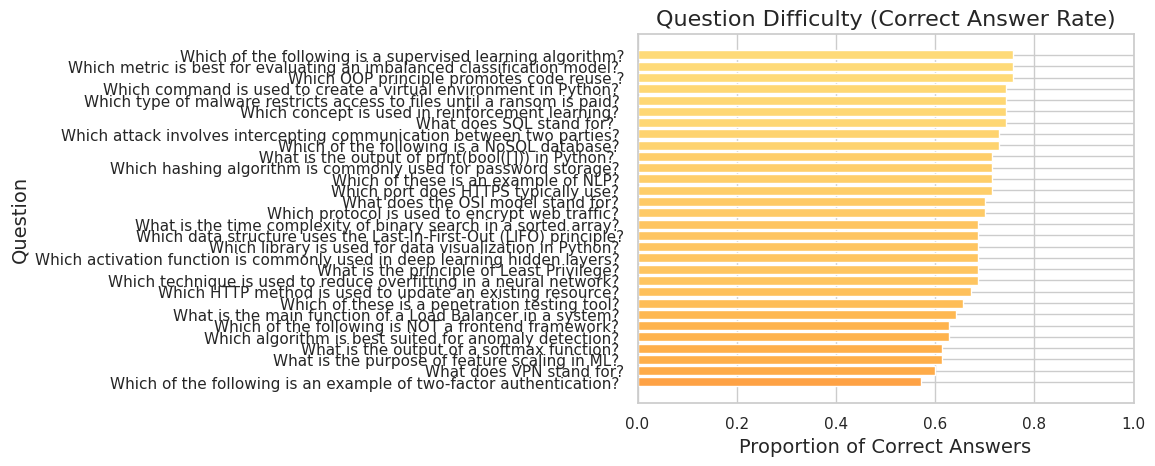

In [ ]:
cmap = sns.color_palette("YlOrRd_r", as_cmap=True)
plt.barh(question_difficulty['Question'], question_difficulty['Correct_Rate'],
         color=plt.cm.YlOrRd_r(question_difficulty['Correct_Rate']))
plt.title('Question Difficulty (Correct Answer Rate)', fontsize=16)
plt.xlabel('Proportion of Correct Answers', fontsize=14)
plt.ylabel('Question', fontsize=14)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('question_difficulty.png', dpi=300, bbox_inches='tight')

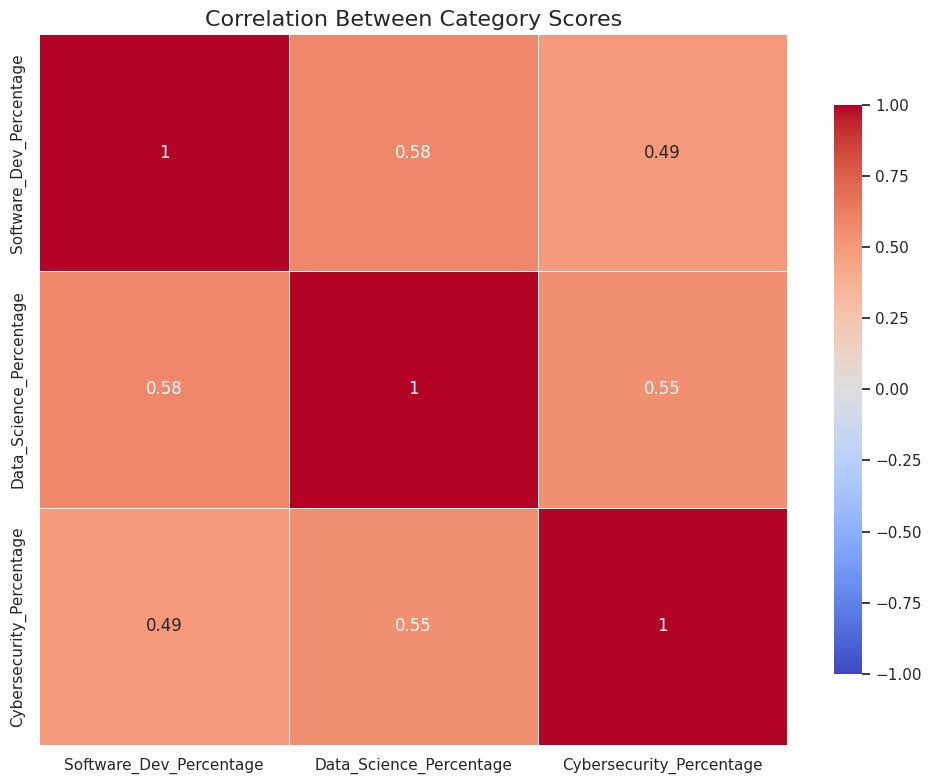

In [ ]:
plt.figure(figsize=(10, 8))
score_cols = ['Software_Dev_Percentage', 'Data_Science_Percentage', 'Cybersecurity_Percentage']
correlation = df[score_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Between Category Scores', fontsize=16)
plt.tight_layout()
plt.savefig('category_correlation.png', dpi=300, bbox_inches='tight')

<ipython-input-111-531584e8fcd5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Name', y='Score_Percentage', data=top_students, palette='viridis')


(0.0, 100.0)

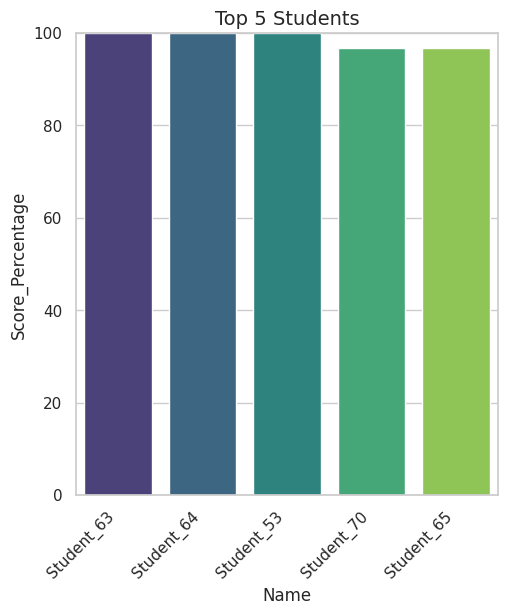

In [ ]:
top_students = df.sort_values('Score_Percentage', ascending=False).head(5)
bottom_students = df.sort_values('Score_Percentage').head(5)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Name', y='Score_Percentage', data=top_students, palette='viridis')
plt.title('Top 5 Students', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

<ipython-input-112-7b32b3177ab2>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Name', y='Score_Percentage', data=bottom_students, palette='viridis')


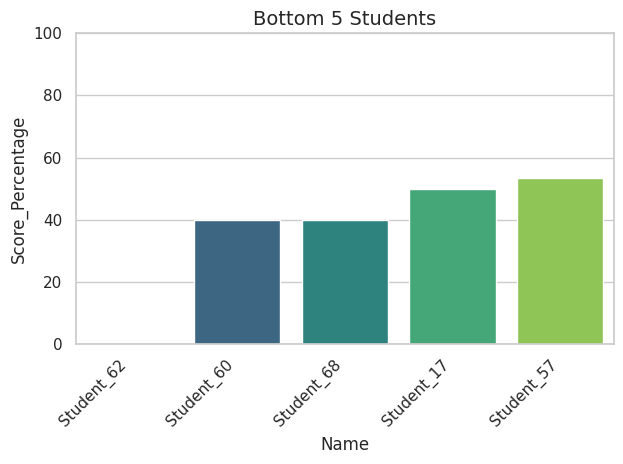

In [ ]:
sns.barplot(x='Name', y='Score_Percentage', data=bottom_students, palette='viridis')
plt.title('Bottom 5 Students', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('top_bottom_students.png', dpi=300, bbox_inches='tight')

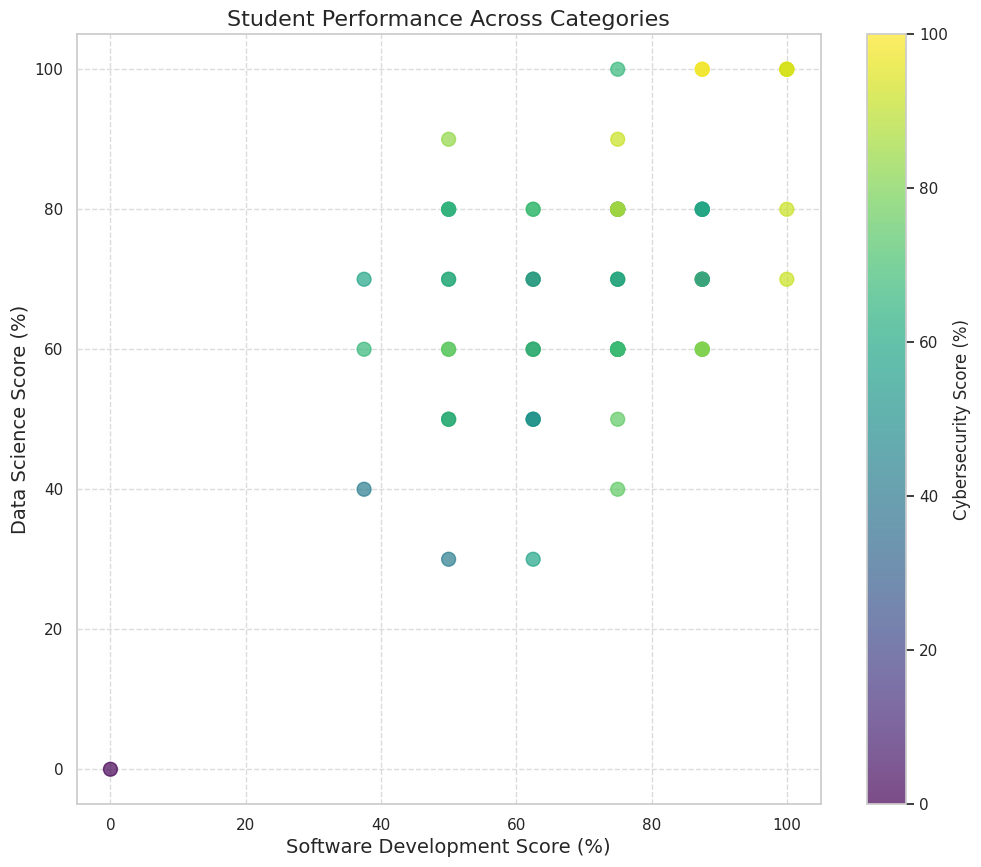

In [ ]:
plt.figure(figsize=(12, 10))
plt.scatter(df['Software_Dev_Percentage'], df['Data_Science_Percentage'],
           c=df['Cybersecurity_Percentage'], cmap='viridis', s=100, alpha=0.7)
plt.colorbar(label='Cybersecurity Score (%)')
plt.title('Student Performance Across Categories', fontsize=16)
plt.xlabel('Software Development Score (%)', fontsize=14)
plt.ylabel('Data Science Score (%)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('category_performance_scatter.png', dpi=300, bbox_inches='tight')

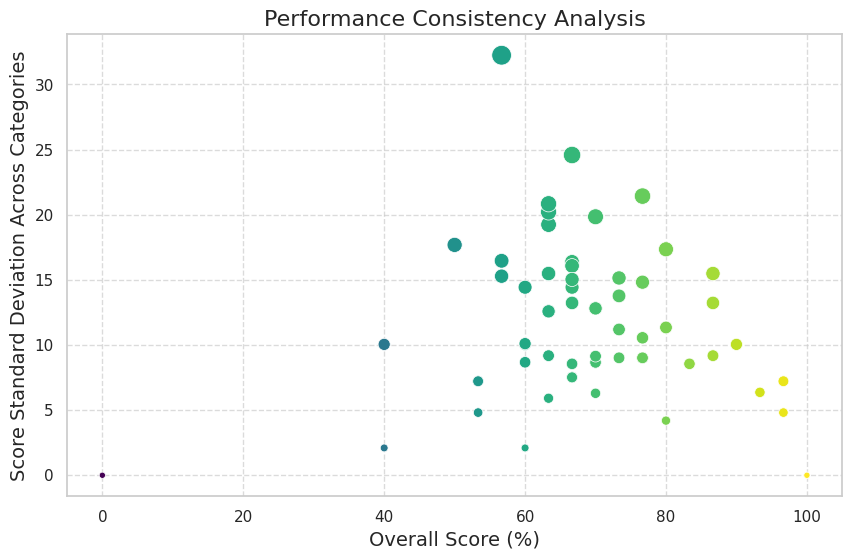

In [ ]:
df['Score_StdDev'] = df[['Software_Dev_Percentage', 'Data_Science_Percentage', 'Cybersecurity_Percentage']].std(axis=1)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Score_Percentage', y='Score_StdDev', data=df, hue='Score_Percentage',
                palette='viridis', size='Score_StdDev', sizes=(20, 200), legend=False)
plt.title('Performance Consistency Analysis', fontsize=16)
plt.xlabel('Overall Score (%)', fontsize=14)
plt.ylabel('Score Standard Deviation Across Categories', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('performance_consistency.png', dpi=300, bbox_inches='tight')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
X = df.drop(columns=['Student_ID', 'Name', 'Email', 'Category_1', 'Category_2', 'Category_3'])
y = df['Category_2']

In [ ]:
X_encoded = X.copy()
for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.79


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       0.00      0.00      0.00         0

    accuracy                           0.79        14
   macro avg       0.50      0.39      0.44        14
weighted avg       1.00      0.79      0.88        14



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import joblib
joblib.dump(model, 'job_recommendation_model.pkl')
print("\nModel saved as 'job_recommendation_model.pkl'!")


Model saved as 'job_recommendation_model.pkl'!
